In [4]:
%matplotlib inline

Read  red-wine.csv into Python as a data frame, use a pandas profiling tool (https://github.com/pandas-profiling/pandas-profiling) to create an HTML file, and paste a screenshot of the HTML file here

In [5]:
import pandas as pd
import ydata_profiling as yp 

import matplotlib.pyplot as plt

# Ensure this package is installed and available

file_path = './red_wine.csv'  # Ensure the file is in your working directory

try:
    # Load the data
    df = pd.read_csv(file_path, low_memory=False)
except FileNotFoundError:
    print(f"No such file or directory: '{file_path}'")
except pd.errors.EmptyDataError:
    print(f"No data in file: '{file_path}'")
except pd.errors.ParserError:
    print(f"Error parsing file: '{file_path}'")
else:
    try:
        # Generate the profiling report
        profile = yp.ProfileReport(df, title='Profiling Report', explorative=True)

        # Save the report
        profile.to_file("red_wine_profiling_report.html")
    except Exception as e:
        print(f"An error occurred while generating the profile report: {str(e)}")

C:\Users\mounac1\AppData\Local\anaconda3\Lib\site-packages\ydata_profiling\profile_report.py:357: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
import pandas as pd

# Load the dataset to examine its contents
file_path = './red_wine.csv'
red_wine_df = pd.read_csv(file_path)

# Display the first few rows to understand the structure of the dataset
red_wine_df.head()

,citric acid,sulphates,alcohol,type
0,0.49,0.63,8.0,low
1,0.66,0.57,8.3,low
2,0.23,0.44,8.5,high
3,0.44,0.84,8.6,low
4,0.08,0.50,8.7,low


Fit a model using each of the following methods and report the performance metrics of 10-fold cross-validation using red-wine.csv as the training set.

In [7]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score

# Preprocess the data
# Encode the target variable
le = LabelEncoder()
red_wine_df['type_encoded'] = le.fit_transform(red_wine_df['type'])  # "low" -> 0, "high" -> 1

# Features and target variable
X = red_wine_df[['citric acid', 'sulphates', 'alcohol']]
y = red_wine_df['type_encoded']

# Define models
models = {
    'Baseline': DummyClassifier(strategy="most_frequent"),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM-Linear': SVC(kernel='linear', probability=True),
    'SVM-RBF': SVC(kernel='rbf', probability=True),
    'Random Forest': RandomForestClassifier()
}

# Initialize a dictionary to store results
results = {}

# Evaluate each model using 10-fold cross-validation
for model_name, model in models.items():
    # Perform cross-validation predictions
    y_pred = cross_val_predict(model, X, y, cv=10, method='predict')
    y_proba = cross_val_predict(model, X, y, cv=10, method='predict_proba')[:, 1] if hasattr(model, "predict_proba") else None
    
    # Calculate accuracy
    accuracy = accuracy_score(y, y_pred)
    
    # Calculate AUC
    if y_proba is not None:
        auc = roc_auc_score(y, y_proba)
    else:
        # For models without predict_proba (e.g., Baseline), we assume a random classifier
        auc = 0.5  # Random classifier AUC
        
    # Store the results
    results[model_name] = {'Accuracy': accuracy, 'AUC': auc}

# Display the results
results_df = pd.DataFrame(results).T
results_df

,Accuracy,AUC
Baseline,0.528897,0.500000
Logistic Regression,0.784588,0.870332
Naive Bayes,0.821366,0.882481
Decision Tree,0.749562,0.755447
SVM-Linear,0.791594,0.868848
SVM-RBF,0.535902,0.835163
Random Forest,0.798599,0.868036


Plot the ROC curve of the Random Forest classifier from the Python package, and paste a screenshot of your ROC curve here.

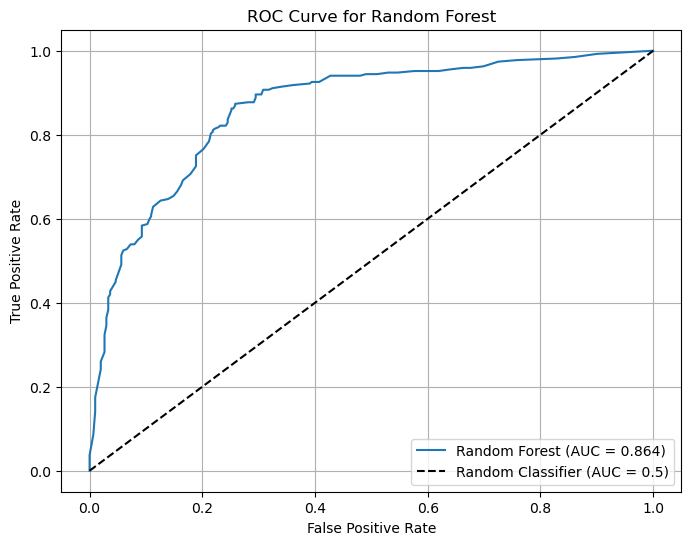

In [8]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve

# Fit the Random Forest model and get probability predictions
rf_model = RandomForestClassifier()
y_proba_rf = cross_val_predict(rf_model, X, y, cv=10, method="predict_proba")[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_proba_rf)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="Random Forest (AUC = {:.3f})".format(roc_auc_score(y, y_proba_rf)))
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [9]:
# Load the new dataset (white-wine.csv) to apply the Naive Bayes model and evaluate its performance.
white_wine_df = pd.read_csv('./white_wine.csv')

# Display the first few rows to understand the structure of this new dataset
white_wine_df.head()


,citric acid,sulphates,alcohol,type
0,0.24,0.52,9.4,low
1,0.49,0.56,9.4,low
2,0.66,0.73,10.0,low
3,0.32,0.77,10.0,low
4,0.38,0.82,10.0,low


Using the best model obtained above in Q2 (according to AUC), running the model on white-wine.csv, and reporting the AUC score, comment on the performance.

In [10]:
# Encode the target variable for white-wine dataset
white_wine_df['type_encoded'] = le.transform(white_wine_df['type'])  # Encode "low" -> 0, "high" -> 1 using the same encoder

# Features and target variable for white-wine dataset
X_white = white_wine_df[['citric acid', 'sulphates', 'alcohol']]
y_white = white_wine_df['type_encoded']

# Initialize the Naive Bayes model
naive_bayes_model = GaussianNB()

# Perform 10-fold cross-validation and calculate AUC for the white-wine dataset
y_proba_white = cross_val_predict(naive_bayes_model, X_white, y_white, cv=10, method="predict_proba")[:, 1]
auc_white = roc_auc_score(y_white, y_proba_white)

auc_white


0.9662487945998072